In [22]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
def edge_weights_from_beliefs(G, public_t, private_t, s, x_metric="l2"):
    """
    Computes directed weights w_ij(t) using:
        x_ij(t) = || p_i(t) - q_j(t) ||
        w_ij(t) = exp(-(x_ij(t)/s)^2) / sum_l a_il

    Parameters
    ----------
    G : nx.Graph
        Base (undirected) graph defining who can talk to whom (a_ij).
    public_t : array (N, d)
        Public belief vectors p_i at timestep t.
    private_t : array (N, d)
        Private belief vectors q_i at timestep t.
    s : float
        Scale parameter.
    x_metric : {"l2","l1","cosine"}
        Distance metric for x_ij.

    Returns
    -------
    edgelist : list[(i,j)]
        Directed edges (both directions for each undirected edge).
    w : np.ndarray
        Directed weights aligned with edgelist.
    """
    P = np.asarray(public_t)
    Q = np.asarray(private_t)
    if P.ndim != 2 or Q.ndim != 2 or P.shape != Q.shape:
        raise ValueError(f"public_t and private_t must both be (N,d). Got {P.shape=} {Q.shape=}")

    deg = dict(G.degree())  # sum_l a_il for unweighted adjacency

    def dist(pi, qj):
        if x_metric == "l2":
            return np.linalg.norm(pi - qj)
        elif x_metric == "l1":
            return np.sum(np.abs(pi - qj))
        elif x_metric == "cosine":
            ni = np.linalg.norm(pi) + 1e-12
            nj = np.linalg.norm(qj) + 1e-12
            return 1.0 - float(np.dot(pi, qj) / (ni * nj))
        else:
            raise ValueError(f"Unknown x_metric: {x_metric}")

    edgelist = []
    w = []

    for (u, v) in G.edges():
        # add both directions because weights are directed
        for i, j in [(u, v), (v, u)]:
            di = deg[i] if deg[i] > 0 else 1
            x_ij = dist(P[int(i)], Q[int(j)])
            w_ij = np.exp(- (x_ij / s) ** 2) / di
            edgelist.append((i, j))
            w.append(w_ij)

    return edgelist, np.asarray(w, dtype=float)

def is_periodic_wrap_edge(i, j, pos, L):
    xi, yi = pos[i]
    xj, yj = pos[j]

    # horizontal wrap (0 <-> L-1)
    if yi == yj and abs(xi - xj) == L - 1:
        return True
    # vertical wrap (0 <-> L-1)
    if xi == xj and abs(yi - yj) == L - 1:
        return True

    return False

data = np.load(r"DHT_N100_SQUARE_log_beliefs-F_weights-g_S0p01_flex1_signal-gaussian_gaussian-stds075_T200_1sims_1.npz")
graph = np.load(r"GRAPH-DHT_N100_SQUARE_log_beliefs-F_weights-g_S0p01_flex1_signal-gaussian_gaussian-stds075_T200_1sims_1.npz")

private_beliefs = data["private"]  # shape (T, N)
public_beliefs = data["public"]    # shape (T, N)
adj_matrix = graph['arr_0'][0]
G = nx.grid_2d_graph(int((np.sqrt(adj_matrix.shape[0]))), int((np.sqrt(adj_matrix.shape[0]))), periodic=True)
L = int(np.sqrt(adj_matrix.shape[0]))  # should be 10 for N=100
G = nx.grid_2d_graph(L, L, periodic=True)
G = nx.convert_node_labels_to_integers(G, ordering="sorted")  # ensures 0..N-1

deg = np.asarray([G.degree(n) for n in range(G.number_of_nodes())], dtype=float)
deg[deg == 0] = 1.0
pos = {n: (n % L, n // L) for n in G.nodes()}

# print(data.files)
# print(data['private'])

edge_list, ws = edge_weights_from_beliefs(G, data['public'][0,0], data['private'][0,0], 0.01)

print(ws)

[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 1.60047053e-139 1.60047053e-139 1.13747142e-264 1.13747142e-264
 0.00000000e+000 0.00000000e+000 5.78588205e-077 5.78588205e-077
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.32607398e-211 3.32607398e-211 4.40742470e-091 4.40742470e-091
 1.39967707e-068 1.39967707e-068 1.02978149e-195 1.02978149e-195
 1.88894623e-232 1.88894623e-232 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 4.27846213e-028 4.27846213e-028
 0.00000000e+000 0.00000000e+000 2.01851668e-187 2.01851668e-187
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 2.69101672e-301 2.691016

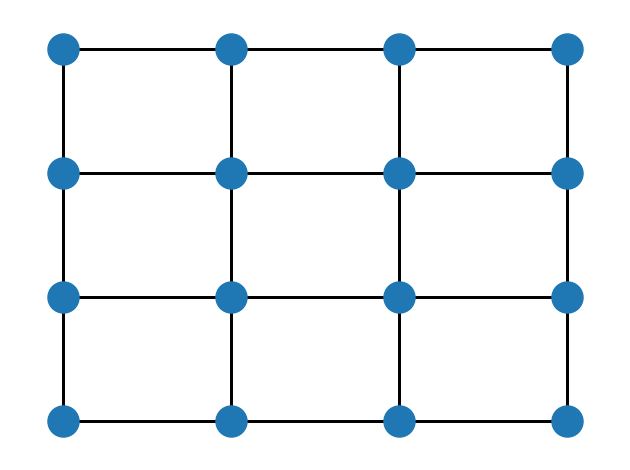

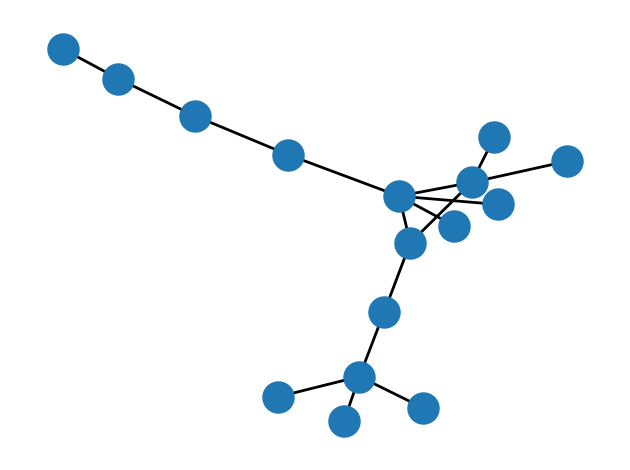

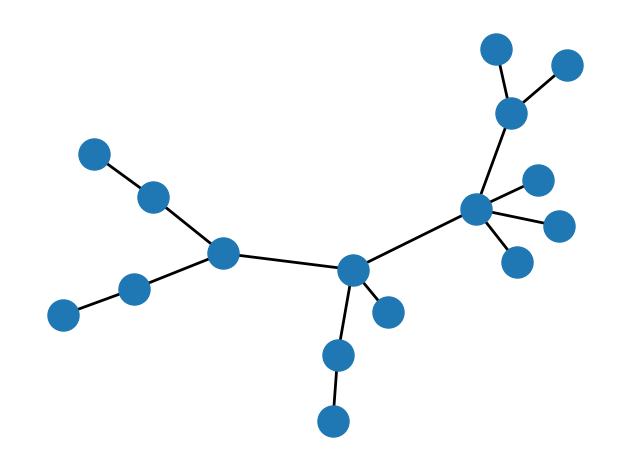

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
N=16
Gs = nx.grid_2d_graph(int(np.sqrt(N)), int(np.sqrt(N)), periodic=True)
GBA = nx.barabasi_albert_graph(N, m=1)
GER = nx.erdos_renyi_graph(N, p=0.2)

pos_grid = {node: node for node in Gs.nodes()}
pos_ba   = nx.spring_layout(GBA, seed=1)
pos_er   = nx.spring_layout(GER, seed=1)

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(Gs, pos=pos_grid, ax=ax, node_size=500, width=2)
# ax.set_title("2D Square Grid", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_square_graphs.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(GER, pos=pos_er, ax=ax, node_size=500, width=2)
# ax.set_title("ER graph", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_ER_graphs.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(GBA, pos=pos_ba, ax=ax, node_size=500, width=2)
# ax.set_title("BA graph", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_BA_graphs.png")
plt.show()

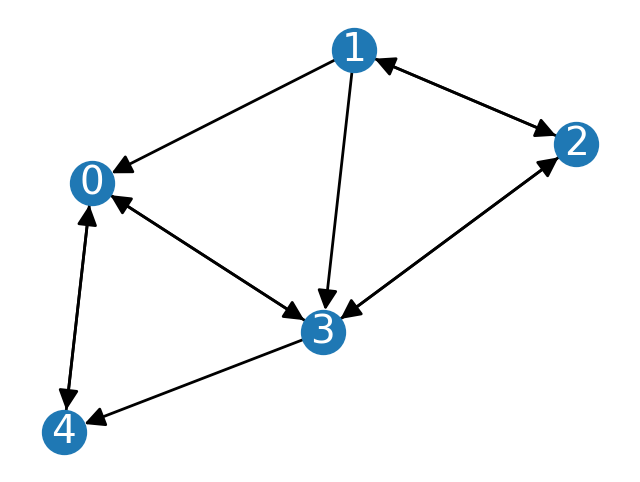

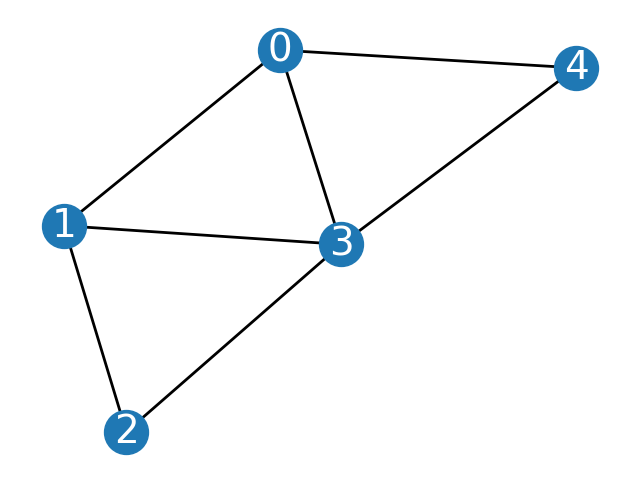

In [8]:
# Gdir = nx.erdos_renyi_graph(5, p=0.5, directed=True)
# Gundir = nx.erdos_renyi_graph(5, p=0.5, directed=False)
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

Aundir  = np.array([[0., 1., 0., 1., 1.,],
                    [1., 0., 1., 1., 0.,],
                    [0., 1., 0., 1., 0.,],
                    [1., 1., 1., 0., 1.,],
                    [1., 0., 0., 1., 0.,]])

Adir =np.array([[0., 0., 0., 1., 1.,],
                [1., 0., 1., 1., 0.,],
                [0., 1., 0., 1., 0.,],
                [1., 0., 1., 0., 1.,],
                [1., 0., 0., 0., 0.,]])

Gundir = nx.from_numpy_array(Aundir)
Gdir = nx.DiGraph()
rows, cols = np.where(Adir == 1)
edges = zip(rows.tolist(), cols.tolist())
Gdir.add_edges_from(edges)

pos_dir = nx.spring_layout(Gdir, seed=1)
pos_undir = nx.spring_layout(Gundir, seed=1)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
nx.draw(Gdir, pos=pos_dir, ax=ax, node_size=1000, with_labels=True, font_color="white", arrowsize=30, font_size=28, width=2)
# ax.set_title("directed graph", fontsize=20)
plt.savefig(r"plots\visualization\example_dir_graph.png")
plt.show()
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
nx.draw(Gundir, pos=pos_undir, ax=ax, node_size=1000, with_labels=True, font_color="white", font_size=28, width=2)
# ax.set_title("undirected graph", fontsize=20)
plt.savefig(r"plots\visualization\example_undir_graphs.png")
plt.show()

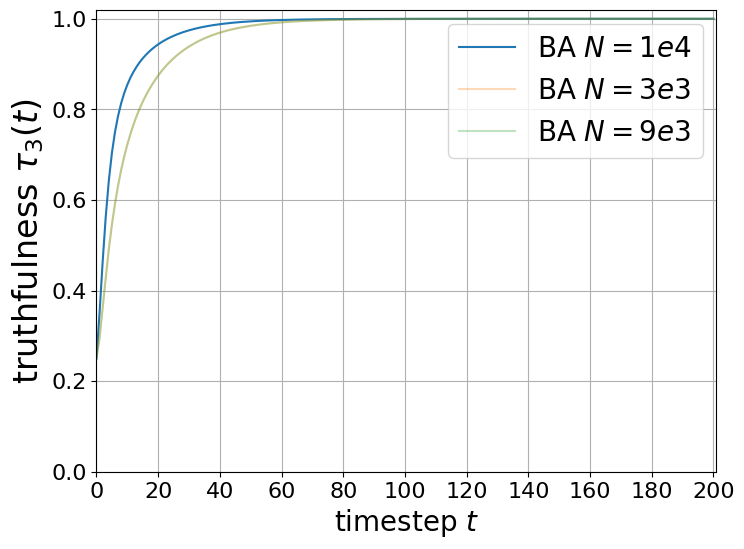

In [7]:
data_BA = np.load(r"N10000\resultsDHT_k1000_BA_m5_gaussian_8flex_uniformweights_T300_20sims_6.npz")
data_ER = np.load(r"N10000\resultsDHT_N10000_k10.0_ER_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_7.npz")
data_ER_small_g = np.load(r"old_vs_new\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds075_T200_200sims_2.npz")
data_BA_small_g = np.load(r"old_vs_new\METRICS_DHT_N100_BA_m5_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds075_T200_200sims_1.npz")
data_BA_N1e3 = np.load(r"large_N\N1e3\BA\METRICS_DHT_N1000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N2e3 = np.load(r"large_N\N2e3\BA\METRICS_DHT_N2000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N3e3 = np.load(r"large_N\N3e3\BA\METRICS_DHT_N3000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N4e3 = np.load(r"large_N\N4e3\BA\METRICS_DHT_N4000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N5e3 = np.load(r"large_N\N5e3\BA\METRICS_DHT_N5000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N6e3 = np.load(r"large_N\N6e3\BA\METRICS_DHT_N6000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N7e3 = np.load(r"large_N\N7e3\BA\METRICS_DHT_N7000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N8e3 = np.load(r"large_N\N8e3\BA\METRICS_DHT_N8000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")
data_BA_N9e3 = np.load(r"large_N\N9e3\BA\METRICS_DHT_N9000_k10.0_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_1.npz")

Tba0 = data_BA["T0"]
Tba3 = data_BA["T3"]
# Ter0 = data_ER["T0"]
Ter3 = data_ER["T3"]

Tba3_g = data_BA_small_g["T3"]
Ter3_g = data_ER_small_g["T3"]

T=201
t = np.arange(0, 201)

plt.figure(figsize=(8,6))
# plt.plot(t, Tba0[1:T:], label=r"BA $\theta=0$")
plt.plot(t, Tba3[:T:], label=r"BA $N=1e4$")
# plt.plot(t, Ter0[1:T:], label=r"ER $\theta=0$")
# plt.plot(t, Ter3[:T:], label=r"ER $N=1e4$", alpha=0.3)
# plt.plot(t, Tba3_g, label=r"BA $N=100$", alpha=0.3)
# plt.plot(t, Tba3_g, label=r"ER $N=100$", alpha=0.3)
# plt.plot(t, data_BA_N1e3["T3"][:T:], label=r"BA $N=1e3$", alpha=0.3)
# plt.plot(t, data_BA_N2e3["T3"][:T:], label=r"BA $N=2e3$", alpha=0.3)
plt.plot(t, data_BA_N3e3["T3"][:T:], label=r"BA $N=3e3$", alpha=0.3)
# plt.plot(t, data_BA_N4e3["T3"][:T:], label=r"BA $N=4e3$", alpha=0.3)
# plt.plot(t, data_BA_N5e3["T3"][:T:], label=r"BA $N=5e3$", alpha=0.3)
# plt.plot(t, data_BA_N6e3["T3"][:T:], label=r"BA $N=6e3$", alpha=0.3)
# plt.plot(t, data_BA_N7e3["T3"][:T:], label=r"BA $N=7e3$", alpha=0.3)
# plt.plot(t, data_BA_N8e3["T3"][:T:], label=r"BA $N=8e3$", alpha=0.3)
plt.plot(t, data_BA_N9e3["T3"][:T:], label=r"BA $N=9e3$", alpha=0.3)
plt.xlabel(r'timestep $t$', fontsize=20)
plt.ylabel(r"truthfulness $\tau_3(t)$", fontsize=24)
plt.legend(fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=16)
plt.xticks(np.arange(0, T, 20), fontsize=16)
plt.grid()
plt.xlim((0, T))
plt.ylim((0,1.02))
# plt.savefig("old_vs_new_truthfulness.png", dpi=400)
plt.show()

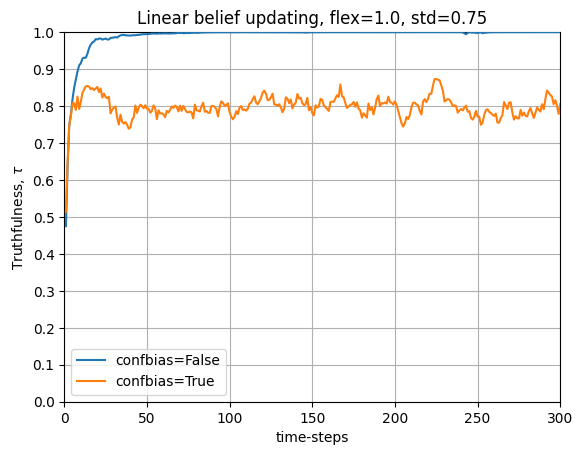

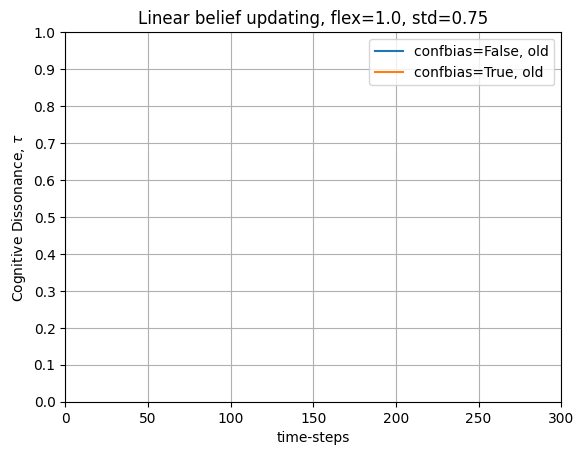

In [ ]:
q1 = np.load("visualization\DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_1sims_1.npz")
q2 = np.load("visualization\DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_1sims_1.npz")
# q3 = np.load("visualization\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
# q4 = np.load("visualization\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_200sims_1.npz")


T1 = truthfulness(q1['private'], 3)
T2 = truthfulness(q2['private'], 3)
# T3 = truthfulness(q3['private'], 3)
# T4 = truthfulness(q4['private'], 3)

CD1 = cognitive_dissonance(q1['private'], q1['public'])
CD2 = cognitive_dissonance(q2['private'], q2['public'])
# CD3 = cognitive_dissonance(q3['private'], q3['public'])
# CD4 = cognitive_dissonance(q4['private'], q4['public'])

t = np.arange(1, len(T1), 1)

plt.figure()
plt.plot(t, T1[1::], label=r"confbias=False", zorder=5)
plt.plot(t, T2[1::], label=r"confbias=True", zorder=5)
# plt.plot(t, T3[1::], label=r"confbias=False, new", zorder=5)
# plt.plot(t, T4[1::], label=r"confbias=True, new", zorder=5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, std=0.75")
plt.savefig(r"visualization\plots\Truthfulness-graphDHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_T300_1sims.png")
plt.show()

0.9980142722857205 0.997894206688055 0.997831033879265
0.9999461820169963 0.9999458015801201 0.9999457596077913


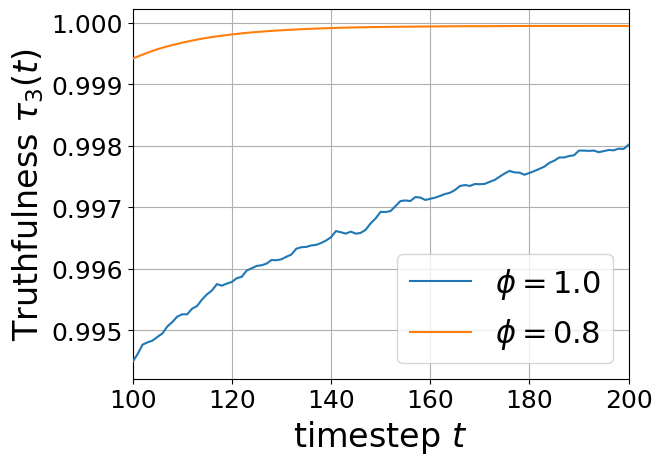

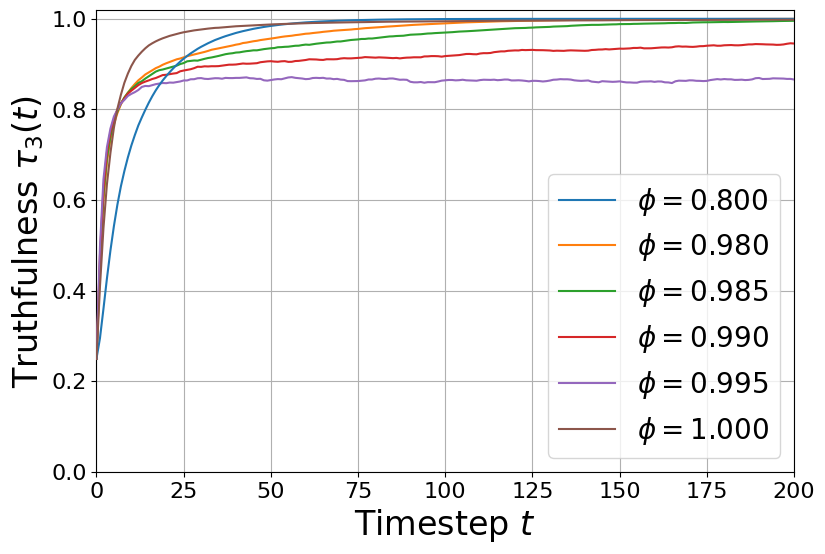

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
q_098 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_098flex_confbias-True_T2000_200sims_1.npz")
q_0985 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0985flex_confbias-True_T2000_200sims_1.npz")
q_099 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_099flex_confbias-True_T2000_200sims_1.npz")
q_0995 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0995flex_confbias-True_T2000_200sims_1.npz")

T_098 = truthfulness(q_098['private'], 3)
T_0985 = truthfulness(q_0985['private'], 3)
T_099 = truthfulness(q_099['private'], 3)
T_0995 = truthfulness(q_0995['private'], 3)
t = np.arange(0, 201, 1)
T_08 = np.load(r"old_vs_new\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds075_T200_200sims_1.npz")
T_05 = np.load(r"old_vs_new\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p5_signal-gaussian_gaussian-stds075_T200_200sims_1.npz")
T_10 = np.load(r"old_vs_new\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex1_signal-gaussian_gaussian-stds075_T200_200sims_1.npz")

print(np.max(T_10['T3'][180:201]), np.median(T_10['T3'][180:201]), np.mean(T_10['T3'][180:201]))
print(np.max(T_08['T3'][180:201]), np.median(T_08['T3'][180:201]), np.mean(T_08['T3'][180:201]))

plt.figure()
plt.plot(np.arange(100, 201), T_10['T3'][100:201:], label=r"$\phi=1.0$", zorder=5)
plt.plot(np.arange(100, 201), T_08['T3'][100:201:], label=r"$\phi=0.8$", zorder=5)
plt.xlabel(r'timestep $t$', fontsize=24)
plt.ylabel(r"Truthfulness $\tau_3(t)$", fontsize=24)
plt.legend(fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18) 
plt.grid()
plt.xlim((100, 200))
plt.savefig("plots/flex_values/flex-values-convergence.png", dpi=400)
plt.show()

plt.figure(figsize=(9,6))
plt.plot(t[:201:], T_08['T3'][:201:], label=r"$\phi=0.800$", zorder=9, alpha=1)
plt.plot(t[:201:], T_098[:201:], label=r"$\phi=0.980$", zorder=5, alpha=1)
plt.plot(t[:201:], T_0985[:201:], label=r"$\phi=0.985$", zorder=6, alpha=1)
plt.plot(t[:201:], T_099[:201:], label=r"$\phi=0.990$", zorder=7, alpha=1)
plt.plot(t[:201:], T_0995[:201:], label=r"$\phi=0.995$", zorder=8, alpha=1)
plt.plot(t[:201:], T_10['T3'][:201:], label=r"$\phi=1.000$", zorder=10, alpha=1)
plt.xlabel(r'Timestep $t$', fontsize=24)
plt.ylabel(r"Truthfulness $\tau_3(t)$", fontsize=24)
plt.legend(fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=16)
plt.xticks(np.arange(0, len(t[:201:])+1, (len(t[:201:])+1)//8), fontsize=16) 
plt.grid()
plt.xlim((0, len(t[:200:])))
plt.ylim((0,1.02))
plt.savefig("plots/flex_values/flex-values-0p98-0p995.png", dpi=400)
plt.show()

In [15]:
# q_std05_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.5_08flex_confbias-True_T300_200sims_1.npz")
# q_std075_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_200sims_1.npz")
# q_std10_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.0_08flex_confbias-True_T300_200sims_1.npz")
# q_std125_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.25_08flex_confbias-True_T300_200sims_1.npz")
# q_std15_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.5_08flex_confbias-True_T300_200sims_1.npz")

q_std05_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_8flex_confbias-True_T300_200sims_1.npz")
q_std075_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_8flex_confbias-True_T300_200sims_1.npz")
q_std10_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_8flex_confbias-True_T300_200sims_1.npz")
q_std125_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_8flex_confbias-True_T300_200sims_1.npz")
q_std15_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_8flex_confbias-True_T300_200sims_1.npz")

# q_std05_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
# q_std075_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
# q_std10_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
# q_std125_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
# q_std15_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

# q_std05_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
# q_std075_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
# q_std10_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
# q_std125_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
# q_std15_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

# T_std05_BA = truthfulness(q_std05_BA['private'], 3)
# T_std075_BA = truthfulness(q_std075_BA['private'], 3)
# T_std10_BA = truthfulness(q_std10_BA['private'], 3)
# T_std125_BA = truthfulness(q_std125_BA['private'], 3)
# T_std15_BA = truthfulness(q_std15_BA['private'], 3)

T_std05_ER = truthfulness(q_std05_ER['private'], 3)
T_std075_ER = truthfulness(q_std075_ER['private'], 3)
T_std10_ER = truthfulness(q_std10_ER['private'], 3)
T_std125_ER = truthfulness(q_std125_ER['private'], 3)
T_std15_ER = truthfulness(q_std15_ER['private'], 3)

# T_std05_BA_basic = truthfulness(q_std05_BA_basic['private'], 3)
# T_std075_BA_basic = truthfulness(q_std075_BA_basic['private'], 3)
# T_std10_BA_basic = truthfulness(q_std10_BA_basic['private'], 3)
# T_std125_BA_basic = truthfulness(q_std125_BA_basic['private'], 3)
# T_std15_BA_basic = truthfulness(q_std15_BA_basic['private'], 3)

# T_std05_ER_basic = truthfulness(q_std05_ER_basic['private'], 3)
# T_std075_ER_basic = truthfulness(q_std075_ER_basic['private'], 3)
# T_std10_ER_basic = truthfulness(q_std10_ER_basic['private'], 3)
# T_std125_ER_basic = truthfulness(q_std125_ER_basic['private'], 3)
# T_std15_ER_basic = truthfulness(q_std15_ER_basic['private'], 3)

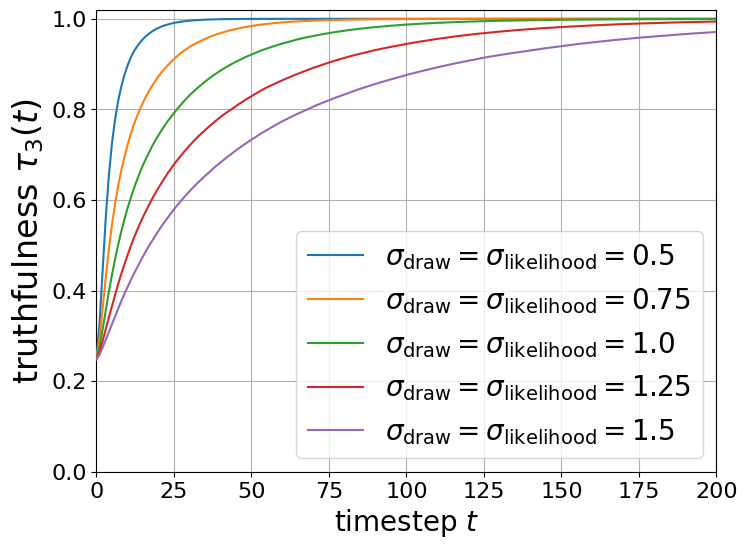

In [3]:
t = np.arange(0, 201, 1)

T_std05_ER = np.load(r"testing\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds05_T200_200sims_1.npz")
T_std075_ER = np.load(r"testing\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds075_T200_200sims_1.npz")
T_std10_ER = np.load(r"testing\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds10_T200_200sims_1.npz")
T_std125_ER = np.load(r"testing\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds125_T200_200sims_1.npz")
T_std15_ER = np.load(r"testing\METRICS_DHT_N100_ER_k10.0_log_beliefs-F_weights-g_S0p6_flex0p8_signal-gaussian_gaussian-stds15_T200_200sims_1.npz")

plt.figure(figsize=(8, 6))
# plt.plot(t, T_std05_BA[1::], label=r"std=0.5, BA", zorder=5, alpha=0.5)
# plt.plot(t, T_std075_BA[1::], label=r"std=0.75, BA", zorder=6, alpha=0.5)
# plt.plot(t, T_std10_BA[1::], label=r"std=1.0, BA", zorder=7, alpha=0.5)
# plt.plot(t, T_std125_BA[1::], label=r"std=1.25, BA", zorder=8, alpha=0.5)
# plt.plot(t, T_std15_BA[1::], label=r"std=1.5, BA", zorder=9, alpha=0.5)
# plt.title(f"phi=0.8, s=0.6")
plt.plot(t, T_std05_ER['T3'], label=r"$\sigma_\mathrm{draw}=\sigma_\mathrm{likelihood}=0.5$", zorder=10)
plt.plot(t, T_std075_ER['T3'], label=r"$\sigma_\mathrm{draw}=\sigma_\mathrm{likelihood}=0.75$", zorder=11)
plt.plot(t, T_std10_ER['T3'], label=r"$\sigma_\mathrm{draw}=\sigma_\mathrm{likelihood}=1.0$", zorder=12)
plt.plot(t, T_std125_ER['T3'], label=r"$\sigma_\mathrm{draw}=\sigma_\mathrm{likelihood}=1.25$", zorder=13)
plt.plot(t, T_std15_ER['T3'], label=r"$\sigma_\mathrm{draw}=\sigma_\mathrm{likelihood}=1.5$", zorder=14)
plt.xlabel(r'timestep $t$', fontsize=20)
plt.ylabel(r"truthfulness $\tau_3(t)$", fontsize=24)
plt.legend(fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=16)
plt.xticks(np.arange(0, len(T_std05_ER['T3'])+1, 25), fontsize=16)
plt.grid()
plt.xlim((0, len(T_std05_ER['T3'])-1))
plt.ylim((0,1.02))
plt.savefig("old_vs_new/truthfulness_s0p5-1p5.png", dpi=400)
plt.show()

# plt.figure()
# plt.plot(t, T_std05_BA_basic[1::], label=r"std=0.5, BA", zorder=5, alpha=0.5)
# plt.plot(t, T_std075_BA_basic[1::], label=r"std=0.75, BA", zorder=6, alpha=0.5)
# plt.plot(t, T_std10_BA_basic[1::], label=r"std=1.0, BA", zorder=7, alpha=0.5)
# plt.plot(t, T_std125_BA_basic[1::], label=r"std=1.25, BA", zorder=8, alpha=0.5)
# plt.plot(t, T_std15_BA_basic[1::], label=r"std=1.5, BA", zorder=9, alpha=0.5)
# plt.plot(t, T_std05_ER_basic[1::], label=r"std=0.5, ER", zorder=10, alpha=0.5)
# plt.plot(t, T_std075_ER_basic[1::], label=r"std=0.75, ER", zorder=11, alpha=0.5)
# plt.plot(t, T_std10_ER_basic[1::], label=r"std=1.0, ER", zorder=12, alpha=0.5)
# plt.plot(t, T_std125_ER_basic[1::], label=r"std=1.25, ER", zorder=13, alpha=0.5)
# plt.plot(t, T_std15_ER_basic[1::], label=r"std=1.5, ER", zorder=14, alpha=0.5)
# plt.grid()
# plt.xlim(0, np.max(t))
# plt.xticks(np.arange(0, np.max(t)+1, 50))
# plt.yticks(np.arange(0, 1.1, 0.1))
# plt.ylim(0, 1)
# plt.legend()
# plt.xlabel("time-steps")
# plt.ylabel(r"Truthfulness, $\tau$")
# plt.title("Linear belief updating, flex=1.0, confbias=False")
# plt.show()